# Predicting Smartphone Addiction — Kaggle Playground S6E8
### End-to-End Notebook: Feature Engineering + Target Encoding + 3-Model Ensemble (LightGBM + XGBoost + CatBoost)

**Pipeline:**
1. Load data
2. Missing value indicators + imputation
3. Feature engineering (ratios / interactions)
4. K-Fold Target Encoding (categorical columns, leakage-free)
5. Train LightGBM (tuned), XGBoost, CatBoost with 5-Fold CV
6. Find best blend weights using OOF predictions
7. Generate final submission.csv


## 1. Install Libraries

In [ ]:
!pip install lightgbm xgboost catboost -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.3 MB/s eta 0:00:00


## 2. Imports

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import LabelEncoder
import lightgbm as lgb
import xgboost as xgb
import catboost as cb
import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42

## 3. Upload & Load Data\nUpload `train.csv` and `test.csv` when prompted.

In [ ]:
from google.colab import files
uploaded = files.upload()   # select train.csv and test.csv

Saving test.csv to test.csv
Saving train.csv to train.csv


In [ ]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

TARGET = "addicted_label"
ID_COL = "id"

print("Train shape:", train.shape)
print("Test shape:", test.shape)
train.head()

Train shape: (691369, 14)
Test shape: (296302, 13)


,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,addicted_label
0,0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,Male,Medium,No,1
1,1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,Female,Medium,No,0
2,2,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,Female,Low,Yes,0
3,3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,Other,Low,NaN,1
4,4,26.0,11.20,1.87,2.81,1.95,5.25,NaN,NaN,13.39,Female,Medium,No,1


## 4. Missing Value Indicators + Imputation

In [ ]:
cat_cols = ["gender", "stress_level", "academic_work_impact"]
num_cols = [c for c in train.columns if c not in cat_cols + [TARGET, ID_COL]]

# Missing indicator columns (create BEFORE filling, so "being missing" itself is a signal)
for c in num_cols + cat_cols:
    train[f"{c}_missing"] = train[c].isnull().astype(int)
    test[f"{c}_missing"] = test[c].isnull().astype(int)

# Numeric missing values -> median (computed on train only)
for c in num_cols:
    med = train[c].median()
    train[c] = train[c].fillna(med)
    test[c] = test[c].fillna(med)

# Categorical missing values -> "Missing" label
for c in cat_cols:
    train[c] = train[c].fillna("Missing")
    test[c] = test[c].fillna("Missing")

print("Missing values handled.")

Missing values handled.


## 5. Feature Engineering (ratios & interactions)

In [ ]:
def add_features(df):
    df["screen_to_sleep_ratio"] = df["daily_screen_time_hours"] / (df["sleep_hours"] + 1)
    df["social_to_screen_ratio"] = df["social_media_hours"] / (df["daily_screen_time_hours"] + 1)
    df["gaming_to_screen_ratio"] = df["gaming_hours"] / (df["daily_screen_time_hours"] + 1)
    df["notif_per_open"] = df["notifications_per_day"] / (df["app_opens_per_day"] + 1)
    df["free_time"] = 24 - df["work_study_hours"] - df["sleep_hours"]
    df["weekend_vs_weekday_diff"] = df["weekend_screen_time"] - df["daily_screen_time_hours"]
    df["total_active_hours"] = df["social_media_hours"] + df["gaming_hours"] + df["work_study_hours"]
    return df

train = add_features(train)
test = add_features(test)

engineered_cols = ["screen_to_sleep_ratio", "social_to_screen_ratio", "gaming_to_screen_ratio",
                    "notif_per_open", "free_time", "weekend_vs_weekday_diff", "total_active_hours"]
missing_cols = [c for c in train.columns if c.endswith("_missing")]

print("Engineered features:", engineered_cols)

Engineered features: ['screen_to_sleep_ratio', 'social_to_screen_ratio', 'gaming_to_screen_ratio', 'notif_per_open', 'free_time', 'weekend_vs_weekday_diff', 'total_active_hours']


## 6. K-Fold Target Encoding (leakage-free)\nEach categorical column gets a numeric column representing the average target rate for that category, computed without leaking each row's own fold.

In [ ]:
def target_encode_kfold(train, test, col, target, n_splits=5, smoothing=10):
    global_mean = train[target].mean()
    train_encoded = np.zeros(len(train))

    skf_te = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    for tr_idx, val_idx in skf_te.split(train, train[target]):
        fold_train = train.iloc[tr_idx]
        means = fold_train.groupby(col)[target].mean()
        counts = fold_train.groupby(col)[target].count()
        smoothed = (means * counts + global_mean * smoothing) / (counts + smoothing)
        train_encoded[val_idx] = train.iloc[val_idx][col].map(smoothed).fillna(global_mean).values

    full_means = train.groupby(col)[target].mean()
    full_counts = train.groupby(col)[target].count()
    full_smoothed = (full_means * full_counts + global_mean * smoothing) / (full_counts + smoothing)
    test_encoded = test[col].map(full_smoothed).fillna(global_mean).values

    return train_encoded, test_encoded

te_cols = []
for c in cat_cols:
    tr_enc, te_enc = target_encode_kfold(train, test, c, TARGET)
    train[f"{c}_target_enc"] = tr_enc
    test[f"{c}_target_enc"] = te_enc
    te_cols.append(f"{c}_target_enc")

# Also keep label-encoded versions (useful for tree splits too)
for c in cat_cols:
    le = LabelEncoder()
    combined = pd.concat([train[c], test[c]], axis=0)
    le.fit(combined)
    train[c] = le.transform(train[c])
    test[c] = le.transform(test[c])

print("Target encoded columns:", te_cols)

Target encoded columns: ['gender_target_enc', 'stress_level_target_enc', 'academic_work_impact_target_enc']


## 7. Final Feature Set

In [ ]:
features = num_cols + cat_cols + missing_cols + engineered_cols + te_cols
X = train[features]
y = train[TARGET]
X_test = test[features]

print(f"Total features: {len(features)}")
print(features)

Total features: 34
['age', 'daily_screen_time_hours', 'social_media_hours', 'gaming_hours', 'work_study_hours', 'sleep_hours', 'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time', 'gender', 'stress_level', 'academic_work_impact', 'age_missing', 'daily_screen_time_hours_missing', 'social_media_hours_missing', 'gaming_hours_missing', 'work_study_hours_missing', 'sleep_hours_missing', 'notifications_per_day_missing', 'app_opens_per_day_missing', 'weekend_screen_time_missing', 'gender_missing', 'stress_level_missing', 'academic_work_impact_missing', 'screen_to_sleep_ratio', 'social_to_screen_ratio', 'gaming_to_screen_ratio', 'notif_per_open', 'free_time', 'weekend_vs_weekday_diff', 'total_active_hours', 'gender_target_enc', 'stress_level_target_enc', 'academic_work_impact_target_enc']


## 8. Train 3 Models with 5-Fold CV
LightGBM (tuned via Optuna earlier), XGBoost, and CatBoost. We also store out-of-fold (OOF) predictions so we can find the best blend weights afterward without leakage.

**Note:** this cell trains 3 boosted models x 5 folds on the full dataset — it can take 40-70 minutes on Colab.

In [ ]:
lgb_params = {
    "learning_rate": 0.07165550064097957,
    "num_leaves": 45,
    "max_depth": 12,
    "min_child_samples": 41,
    "subsample": 0.9750910653807606,
    "colsample_bytree": 0.6530918510565088,
    "reg_alpha": 1.7535892408913756,
    "reg_lambda": 8.581895359959328,
    "n_estimators": 2000,
    "random_state": RANDOM_STATE,
    "verbose": -1,
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

test_preds_lgb = np.zeros(len(X_test))
test_preds_xgb = np.zeros(len(X_test))
test_preds_cat = np.zeros(len(X_test))
oof_lgb = np.zeros(len(X))
oof_xgb = np.zeros(len(X))
oof_cat = np.zeros(len(X))
val_scores = {"lgb": [], "xgb": [], "cat": []}

for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

    # LightGBM
    m_lgb = lgb.LGBMClassifier(**lgb_params)
    m_lgb.fit(X_tr, y_tr, eval_set=[(X_val, y_val)],
              callbacks=[lgb.early_stopping(80, verbose=False)])

    # XGBoost
    m_xgb = xgb.XGBClassifier(
        n_estimators=2000, learning_rate=0.03, max_depth=8,
        subsample=0.85, colsample_bytree=0.7,
        random_state=RANDOM_STATE, eval_metric="logloss", verbosity=0,
        early_stopping_rounds=80
    )
    m_xgb.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)

    # CatBoost
    m_cat = cb.CatBoostClassifier(
        iterations=2000, learning_rate=0.03, depth=8,
        random_state=RANDOM_STATE, verbose=0, early_stopping_rounds=80
    )
    m_cat.fit(X_tr, y_tr, eval_set=(X_val, y_val))

    for name, m in [("lgb", m_lgb), ("xgb", m_xgb), ("cat", m_cat)]:
        acc = (m.predict(X_val) == y_val).mean()
        val_scores[name].append(acc)
        print(f"Fold {fold} | {name}: {acc:.5f}")

    oof_lgb[val_idx] = m_lgb.predict_proba(X_val)[:, 1]
    oof_xgb[val_idx] = m_xgb.predict_proba(X_val)[:, 1]
    oof_cat[val_idx] = m_cat.predict_proba(X_val)[:, 1]

    test_preds_lgb += m_lgb.predict_proba(X_test)[:, 1] / skf.n_splits
    test_preds_xgb += m_xgb.predict_proba(X_test)[:, 1] / skf.n_splits
    test_preds_cat += m_cat.predict_proba(X_test)[:, 1] / skf.n_splits
    print()

for name in val_scores:
    print(f"{name} mean acc: {np.mean(val_scores[name]):.5f}")

Fold 1 | lgb: 0.90141
Fold 1 | xgb: 0.90211
Fold 1 | cat: 0.89623

Fold 2 | lgb: 0.90225
Fold 2 | xgb: 0.90271
Fold 2 | cat: 0.89872

Fold 3 | lgb: 0.90312
Fold 3 | xgb: 0.90308
Fold 3 | cat: 0.89846

Fold 4 | lgb: 0.90359
Fold 4 | xgb: 0.90488
Fold 4 | cat: 0.89983

Fold 5 | lgb: 0.90154
Fold 5 | xgb: 0.90181
Fold 5 | cat: 0.89711

lgb mean acc: 0.90238
xgb mean acc: 0.90292
cat mean acc: 0.89807


## 9. Find Best Blend Weights (grid search on OOF predictions)

In [ ]:
best_acc = 0
best_weights = None

for w_lgb in np.arange(0, 1.05, 0.1):
    for w_xgb in np.arange(0, 1.05 - w_lgb, 0.1):
        w_cat = 1 - w_lgb - w_xgb
        if w_cat < -1e-9:
            continue
        blend = w_lgb * oof_lgb + w_xgb * oof_xgb + w_cat * oof_cat
        acc = ((blend >= 0.5).astype(int) == y).mean()
        if acc > best_acc:
            best_acc = acc
            best_weights = (round(w_lgb, 2), round(w_xgb, 2), round(w_cat, 2))

print(f"Best blend OOF accuracy: {best_acc:.5f}")
print(f"Best weights -> lgb: {best_weights[0]}, xgb: {best_weights[1]}, cat: {best_weights[2]}")

Best blend OOF accuracy: 0.90326
Best weights -> lgb: 0.5, xgb: 0.5, cat: 0.0


## 10. Feature Importance (from last-fold LightGBM, for reference)

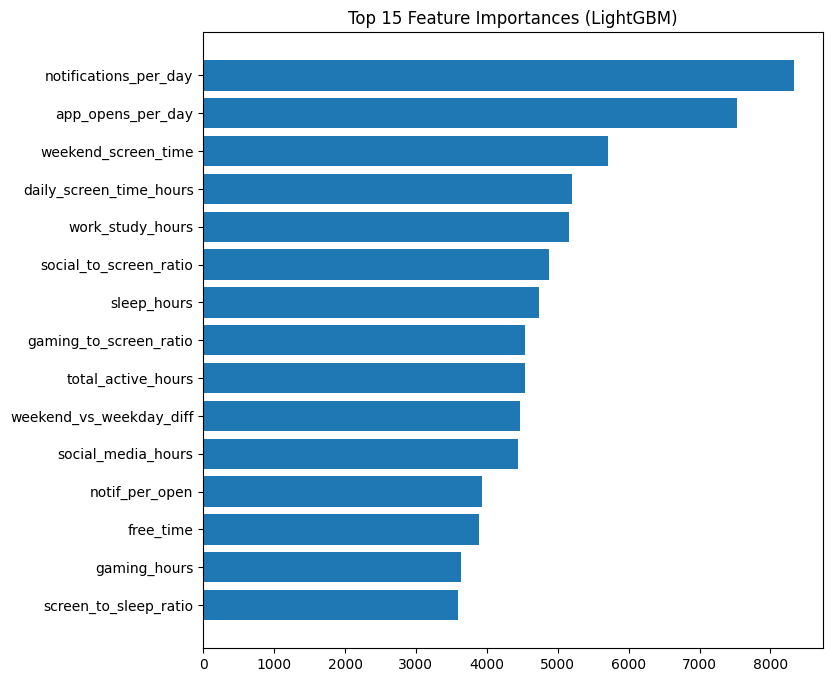

,feature,importance
6,notifications_per_day,8328
7,app_opens_per_day,7528
8,weekend_screen_time,5706
1,daily_screen_time_hours,5201
4,work_study_hours,5164
25,social_to_screen_ratio,4870
5,sleep_hours,4733
26,gaming_to_screen_ratio,4538
30,total_active_hours,4532
29,weekend_vs_weekday_diff,4464


In [ ]:
import matplotlib.pyplot as plt

importance = pd.DataFrame({
    "feature": features,
    "importance": m_lgb.feature_importances_
}).sort_values("importance", ascending=False)

plt.figure(figsize=(8, 8))
plt.barh(importance["feature"][:15], importance["importance"][:15])
plt.gca().invert_yaxis()
plt.title("Top 15 Feature Importances (LightGBM)")
plt.show()

importance.head(15)

## 11. Final Predictions & Submission File

In [ ]:
w_lgb, w_xgb, w_cat = best_weights
final_proba = w_lgb * test_preds_lgb + w_xgb * test_preds_xgb + w_cat * test_preds_cat
final_preds = (final_proba >= 0.5).astype(int)

print("Prediction distribution:", np.bincount(final_preds))

submission = pd.DataFrame({
    ID_COL: test[ID_COL],
    TARGET: final_preds
})
submission.to_csv("submission.csv", index=False)
submission.head()

Prediction distribution: [ 83918 212384]


,id,addicted_label
0,691369,1
1,691370,1
2,691371,1
3,691372,1
4,691373,1


## 12. Download Submission

In [ ]:
from google.colab import files
files.download("submission.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>